In [ ]:
"""
Main notebook for running tracking scores.

TODO:
Each parameter needs to be normalised from 0 to 1 across the set of compared algorithms, yielding a maximum composite skill score of 4.
Higher-scoring algorithms are those that efficiently detect storms with greater current or future severe threat while minimising detection of weak,
short-lived storms.
"""

'\nMain notebook for running tracking scores.\n'

In [4]:
import glob

from matplotlib import pyplot as plt

from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import best_track
import readers

In [5]:
def run_scores(df, best_track_df):
    """
    Calculate tracking scores for each track in the DataFrame.
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with track data
    best_track_df : pandas.DataFrame
        DataFrame with best track data

    Returns
    -------
    tuple of lists
        consistency_scores, duration_scores, linearity_scores, best_track_scores
    """

    unique_track_ids = df['track_id'].unique()
    consistency_scores = []
    duration_scores = []
    linearity_scores = []
    best_track_scores = []

    minimum_length = 2

    for track_id in unique_track_ids:
        subset_df = df[df['track_id'] == track_id]
        subset_n = len(subset_df)
        if subset_n < minimum_length:
            continue

        #consistency score
        subset_area = np.array(subset_df['area'])
        consistency_scores.append(np.sum(np.abs(subset_area[1:]-subset_area[:-1])/subset_area[:-1]) / (subset_n - 1))

        #duration score
        duration_scores.append((np.max(subset_df['timestamp'])-np.min(subset_df['timestamp'])).total_seconds() / 60)

        #linearity score
        #calculate best-fit line for lat-lon points using np.polyfit
        subset_lon = np.array(subset_df['lon'])
        subset_lat = np.array(subset_df['lat'])
        if len(subset_lon) < 3:
            linearity_scores.append(np.nan)
            continue
        p = np.polyfit(subset_lon, subset_lat, 1)
        #calculate r-squared value of subset points to the polyfit p
        lat_fit = np.polyval(p, subset_lon)
        ss_res = np.sum((subset_lat - lat_fit) ** 2)
        ss_tot = np.sum((subset_lat - np.mean(subset_lat)) ** 2)
        r_squared = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0
        linearity_scores.append(r_squared)

    #loop through each row in best_track_df and check if track_id is the same as init_track_id
    best_track_scores = 0
    for index, row in best_track_df.iterrows():
        if row['initial_track_id'] == row['track_id']:
            best_track_scores += 1
        else:
            best_track_scores += 0.5
    #divide best_track_scores by number of cell in original df
    best_track_scores = best_track_scores/len(df)

    return consistency_scores, duration_scores, linearity_scores, best_track_scores

def plot_track(df, track_ids=None, figsize=(12, 10), title='Storm Tracks'):
    """
    Plot all storm tracks on one plot.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Original DataFrame with track data
    track_ids : list, optional
        List of specific track_ids to plot. If None, plots all tracks.
    figsize : tuple
        Figure size (width, height)
    """
    
    if track_ids is None:
        track_ids = df['track_id'].unique()
    
    # Create figure
    fig, ax = plt.subplots(figsize=figsize)
    
    # Generate distinct colors for each track
    colors = plt.cm.tab20(np.linspace(0, 1, len(track_ids)))
    
    for idx, track_id in enumerate(track_ids):
        color = colors[idx]
        
        # Get track data
        track_data = df[df['track_id'] == track_id].sort_values('timestamp')

        # Extract observed positions
        x_obs = track_data['lon'].values
        y_obs = track_data['lat'].values
        
        # Plot observed track
        ax.plot(x_obs, y_obs, 'o-', color=color, label=f'Track {track_id}', 
                markersize=2, linewidth=0.5, alpha=0.7)

    # Labels and formatting
    ax.set_xlabel('X (deg)', fontsize=12)
    ax.set_ylabel('Y (deg)', fontsize=12)
    ax.set_title(title, fontsize=14, fontweight='bold')
    #ax.legend(fontsize=10, loc='best', ncol=max(1, len(track_ids)//10))
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='datalim')
    
    plt.tight_layout()
    plt.show()

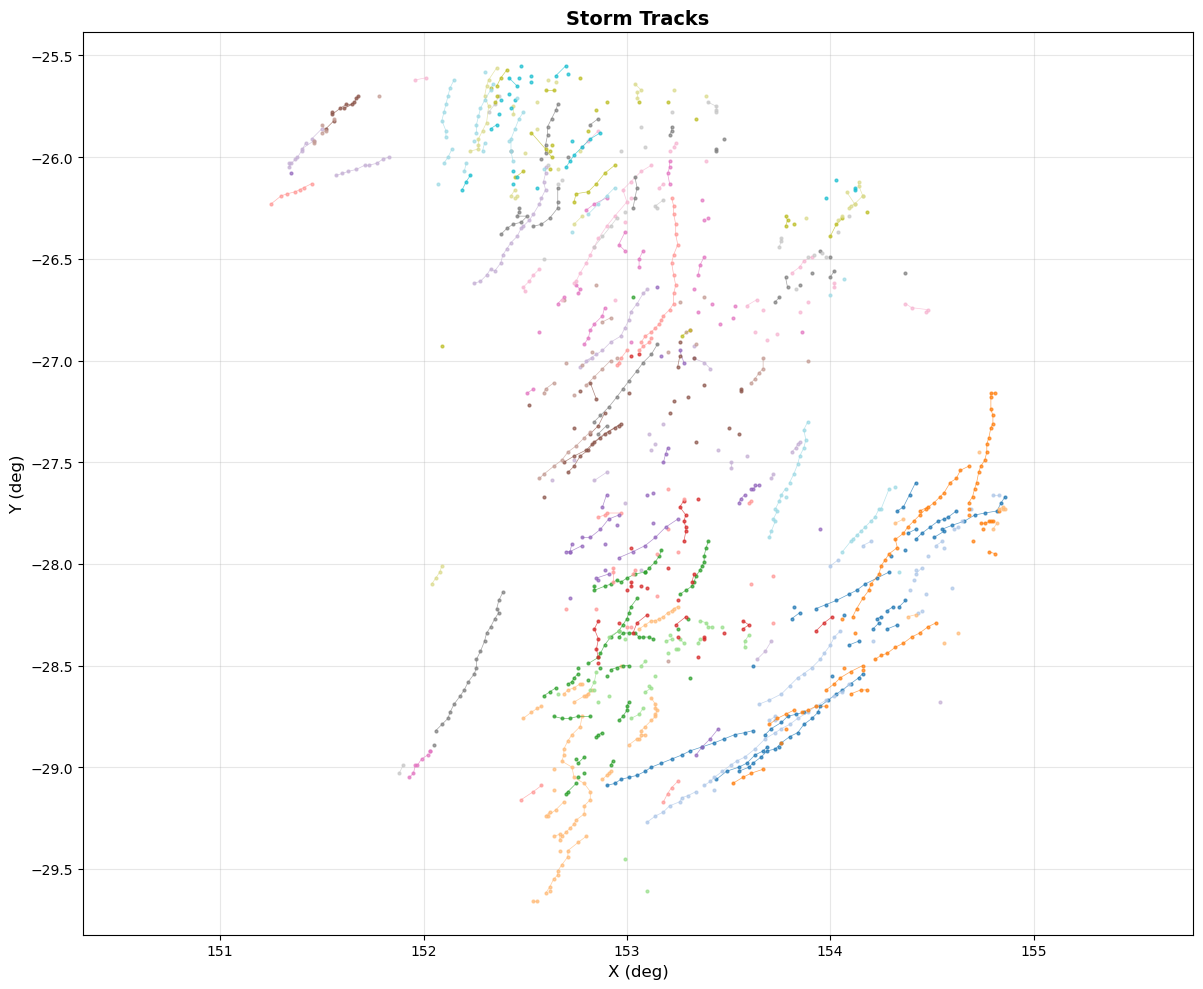

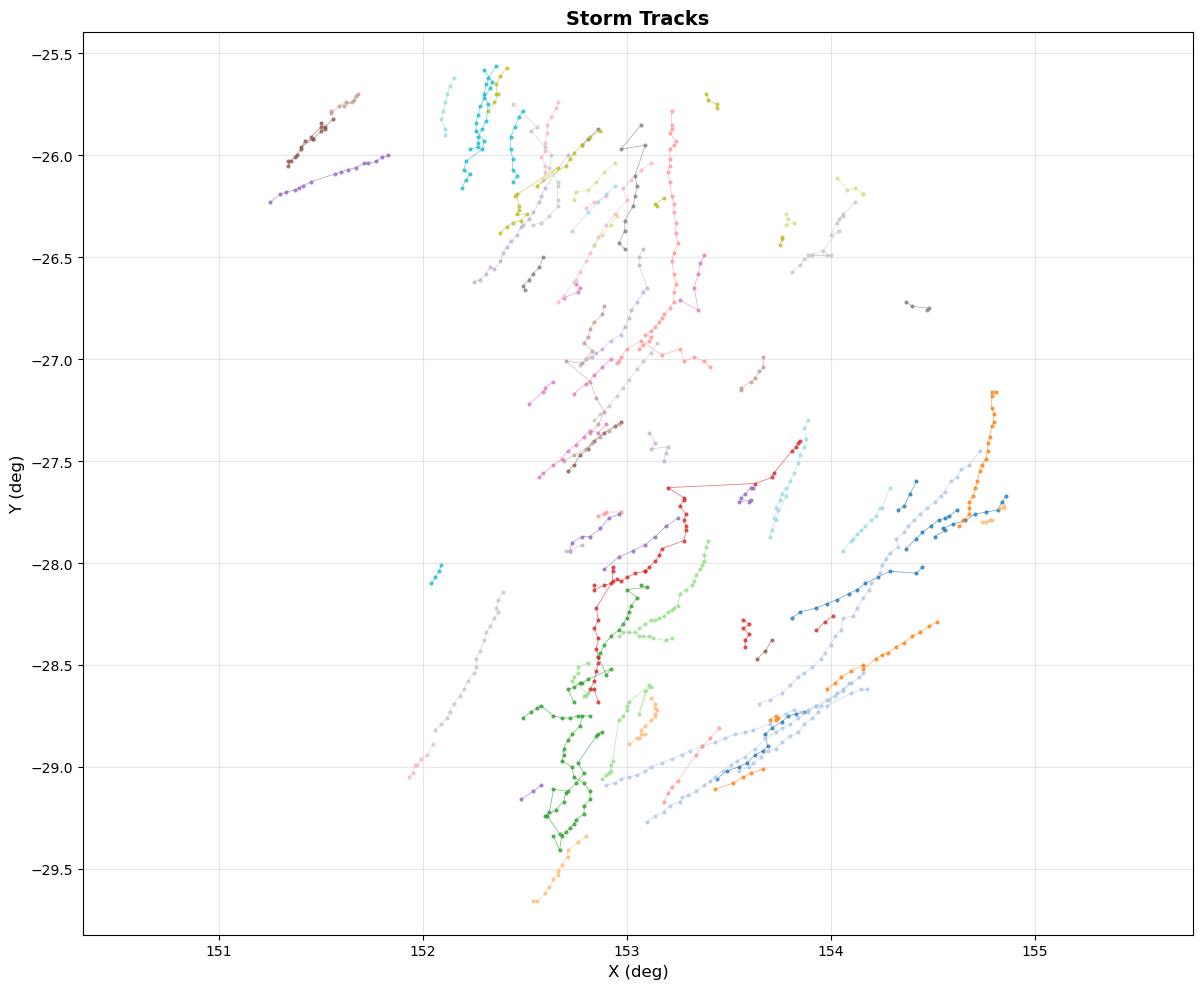

--- Running scores on original track dataframe only ---
Consistency score: 0.3315967048636215
Duration score: 18.110765550239233
Linearity score: 0.8235722565678213
Best track scores: 0.5838788870703764

--- Running scores on best track dataframe only ---
Consistency score: 0.6155640556474573
Duration score: 50.23255813953487
Linearity score: 0.7800774980765838


/scratch/kl02/jss548/tmp/ipykernel_916974/1875577883.py:46: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(subset_lon, subset_lat, 1)


In [6]:
#TITAN ASCII data
reflectivity_lvl = 45
dataset_ffn = f'/g/data/kl02/jss548/track_scores/titan/ascii/marburg2025_{reflectivity_lvl}/20251124.storms_to_tifs'
track_df = readers.load_titan_ascii(dataset_ffn)
plot_track(track_df)

# run best track algorithm
best_track_df = best_track.main(track_df, n_iterations=5)
plot_track(best_track_df)
print('--- Running scores on original track dataframe only ---')
consistency_scores, duration_scores, linearity_scores, best_track_scores = run_scores(track_df, best_track_df)
print("Consistency score:", np.mean(consistency_scores))
print("Duration score:", np.mean(duration_scores))
print("Linearity score:", np.nanmean(linearity_scores))
print("Best track scores:", best_track_scores)

print()
print('--- Running scores on best track dataframe only ---')
consistency_scores, duration_scores, linearity_scores, best_track_scores = run_scores(best_track_df, best_track_df)
print("Consistency score:", np.mean(consistency_scores))
print("Duration score:", np.mean(duration_scores))
print("Linearity score:", np.nanmean(linearity_scores))

In [8]:
#AINT
#load data
track_df = readers.load_aint('/g/data/rq0/admin/aint/2/2020/2_20200119_aint.csv')
# run best track algorithm
best_track_df = best_track.main(track_df, n_iterations=5)

print('--- Running scores on original track dataframe only ---')
consistency_scores, duration_scores, linearity_scores, best_track_scores = run_scores(track_df, best_track_df)
print("Consistency score:", np.mean(consistency_scores))
print("Duration score:", np.mean(duration_scores))
print("Linearity score:", np.nanmean(linearity_scores))
print("Best track scores:", best_track_scores)

print()
print('--- Running scores on best track dataframe only ---')
consistency_scores, duration_scores, linearity_scores, best_track_scores = run_scores(best_track_df, best_track_df)
print("Consistency score:", np.mean(consistency_scores))
print("Duration score:", np.mean(duration_scores))
print("Linearity score:", np.nanmean(linearity_scores))

--- Running scores on original track dataframe only ---
Consistency score: 0.3786188778643249
Duration score: 31.775
Linearity score: 0.5750775075258464
Best track scores: 0.7473076923076923

--- Running scores on best track dataframe only ---
Consistency score: 0.4281911178670441
Duration score: 55.818501529051986
Linearity score: 0.49670812838610356
